In [1]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
from natsort import natsorted

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt

from tqdm import tqdm

Load MNI mask for cleaning betas

In [2]:
maskDir = 'F:\yujun\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

In [3]:
mask.get_fdata().shape

(91, 109, 91)

Select beta series

In [4]:
dataDir = '../GLM_singletrial/betas/'
subs = os.listdir(dataDir)
sub = subs[1]

In [5]:
beta_idx = []
for i in range(0 ,10): # runs
    id = [(x + 66*i) for x in range(1,61)]
    beta_idx.append(id)
beta_id = np.array(beta_idx).reshape(1, -1)

In [6]:
beta_id

array([[  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  67,  68,  69,  70,  71,
         72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
        124, 125, 126, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
        182, 183, 184, 185, 186, 187, 188, 189, 190

In [7]:
sub_dir = os.path.join(dataDir, sub)
filenames = os.listdir(sub_dir)
# Extract the IDs from the filenames
file_ids = [int(os.path.splitext(filename)[0].split('_')[1]) for filename in filenames if os.path.splitext(filename)[0].split('_')[0] == 'beta']
# Filter the filenames based on the ID list
selected_filenames = [filename for filename, file_id in zip(filenames, file_ids) if file_id in beta_id]
print(f'Number of betas for the subject: {len(selected_filenames)}')

Number of betas for the subject: 600


In [8]:
selected_filenames

['beta_0001.nii',
 'beta_0002.nii',
 'beta_0003.nii',
 'beta_0004.nii',
 'beta_0005.nii',
 'beta_0006.nii',
 'beta_0007.nii',
 'beta_0008.nii',
 'beta_0009.nii',
 'beta_0010.nii',
 'beta_0011.nii',
 'beta_0012.nii',
 'beta_0013.nii',
 'beta_0014.nii',
 'beta_0015.nii',
 'beta_0016.nii',
 'beta_0017.nii',
 'beta_0018.nii',
 'beta_0019.nii',
 'beta_0020.nii',
 'beta_0021.nii',
 'beta_0022.nii',
 'beta_0023.nii',
 'beta_0024.nii',
 'beta_0025.nii',
 'beta_0026.nii',
 'beta_0027.nii',
 'beta_0028.nii',
 'beta_0029.nii',
 'beta_0030.nii',
 'beta_0031.nii',
 'beta_0032.nii',
 'beta_0033.nii',
 'beta_0034.nii',
 'beta_0035.nii',
 'beta_0036.nii',
 'beta_0037.nii',
 'beta_0038.nii',
 'beta_0039.nii',
 'beta_0040.nii',
 'beta_0041.nii',
 'beta_0042.nii',
 'beta_0043.nii',
 'beta_0044.nii',
 'beta_0045.nii',
 'beta_0046.nii',
 'beta_0047.nii',
 'beta_0048.nii',
 'beta_0049.nii',
 'beta_0050.nii',
 'beta_0051.nii',
 'beta_0052.nii',
 'beta_0053.nii',
 'beta_0054.nii',
 'beta_0055.nii',
 'beta_005

Resample MNI mask

In [9]:
temp_nii_path = os.path.join(dataDir, sub, selected_filenames[1])
temp_nii_data = nib.load(temp_nii_path)

In [10]:
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)

In [11]:
resampled_mask.shape

(79, 95, 79)

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_stat_map.py:219: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  bg_img = load_mni152_template()
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "



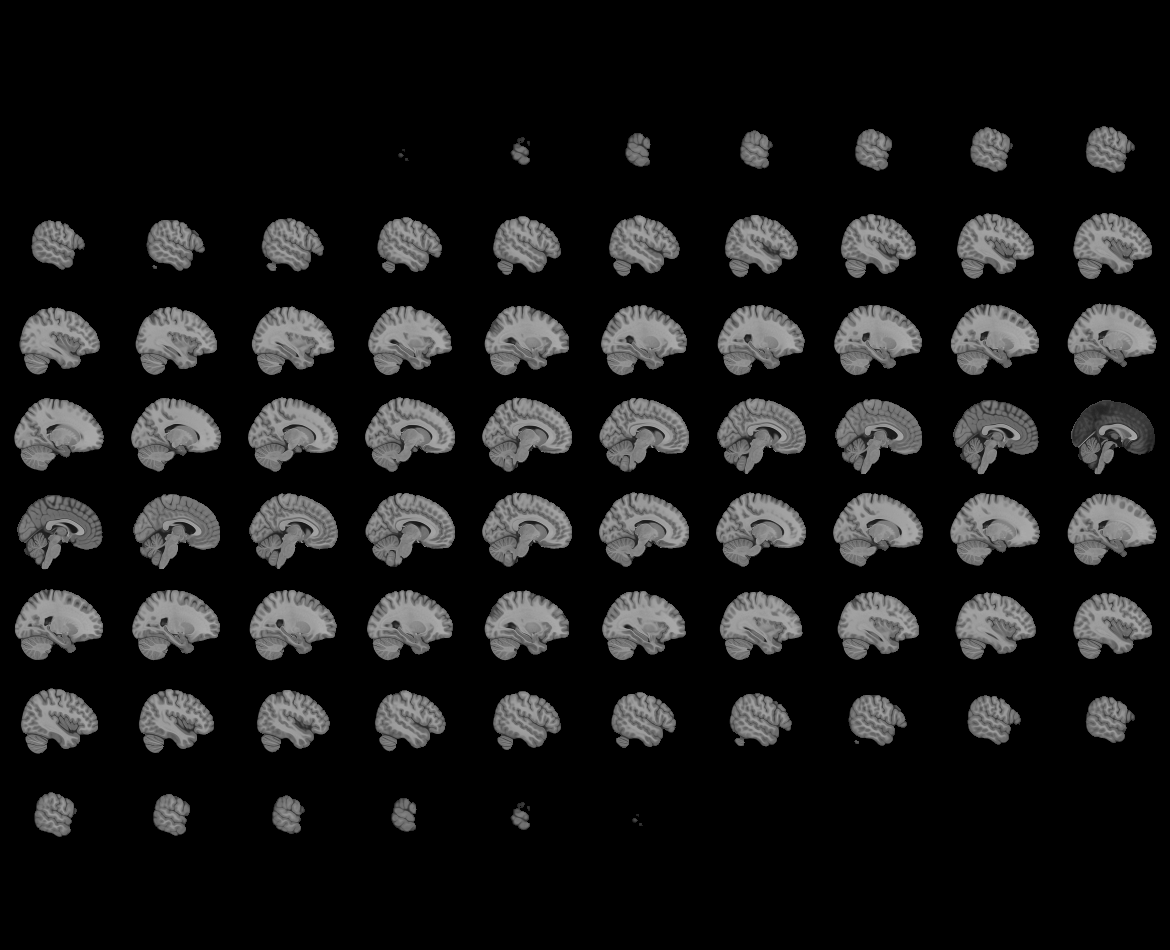
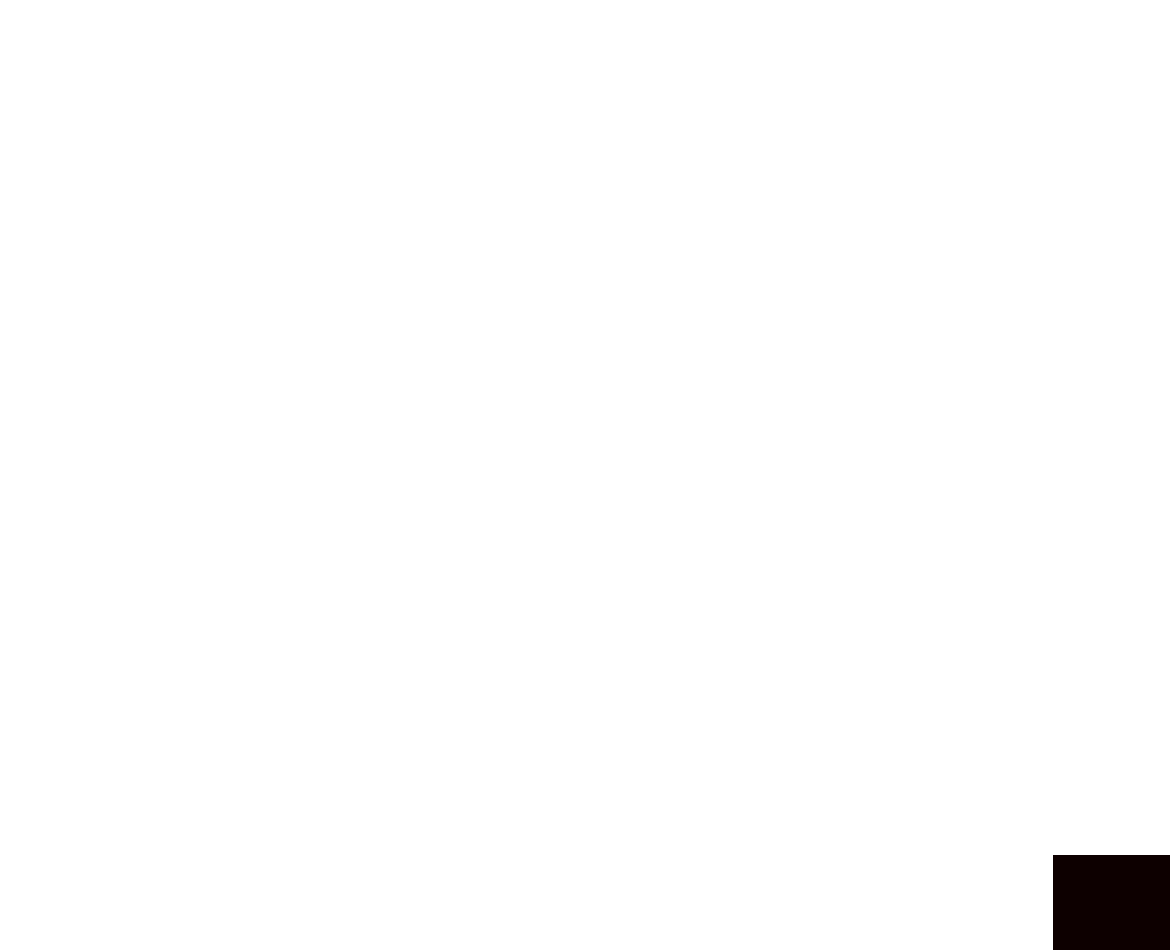

In [13]:
view = plotting.view_img(resampled_mask)
view

Load beta series and apply mask

In [12]:
beta_arrays = []
for i in range(len(selected_filenames)):
    # Load the NIfTI file
    file_path = os.path.join(dataDir, sub, selected_filenames[i])
    nii_data = nib.load(file_path)
    # Apply the mask to the NIfTI image
    masked_data = masking.apply_mask(nii_data, resampled_mask)
    # Get the mask's indices in the original 3D shape
    mask_indices = np.where(resampled_mask.get_fdata())
    # Create a new 3D array filled with zeros
    reshaped_data = np.zeros(nii_data.shape)
    # Fill the new 3D array with the values from the masked data
    reshaped_data[mask_indices] = masked_data
    beta_arrays.append(reshaped_data)

In [13]:
len(beta_arrays)

600

In [14]:
beta_series = np.array(beta_arrays)
beta_series.shape

(600, 79, 95, 79)

Load stimuli sequence

In [15]:
stim_dir = 'F:\yujun\projects\LAB_IAPS_AI\data\stimulus_v2'
stim_files = natsorted(os.listdir(stim_dir))
stim_files

['r1.txt',
 'r2.txt',
 'r3.txt',
 'r4.txt',
 'r5.txt',
 'r6.txt',
 'r7.txt',
 'r8.txt',
 'r9.txt',
 'r10.txt']

In [16]:
stimuli = []
for i, file in enumerate(stim_files):
    txt_path = os.path.join(stim_dir, file)
    data_array = np.loadtxt(txt_path, dtype=str)
    stimuli.append(data_array)
stimuli = np.array(stimuli).flatten()

In [17]:
stimuli

array(['2045_2.jpg', '6211_0.jpg', '5395_2.jpg', '3230_0.jpg', '2550.jpg',
       '1510_2.jpg', '2499.jpg', '3016_1.jpg', '2314_0.jpg', '4574_2.jpg',
       '2580_1.jpg', '9140.jpg', '9300_1.jpg', '5470_2.jpg', '2850_1.jpg',
       '5665.jpg', '5779.jpg', '9905_2.jpg', '4505.jpg', '2314.jpg',
       '9140_2.jpg', '9075_0.jpg', '9570.jpg', '1419_2.jpg', '2010.jpg',
       '2550_0.jpg', '4597.jpg', '4601_0.jpg', '3016.jpg', '1640_0.jpg',
       '4180.jpg', '9430.jpg', '5600.jpg', '2446_2.jpg', '3230.jpg',
       '4210_0.jpg', '2300_0.jpg', '5455.jpg', '9491.jpg', '4604.jpg',
       '9570_1.jpg', '4601.jpg', '4001_2.jpg', '4628.jpg', '1205.jpg',
       '3051_0.jpg', '4505_1.jpg', '2540.jpg', '5661.jpg', '1604_2.jpg',
       '5661_0.jpg', '5551.jpg', '2900.1.jpg', '9909.jpg', '7405_0.jpg',
       '2850.jpg', '4150.jpg', '3101.jpg', '6940_2.jpg', '9900.jpg',
       '9300.jpg', '4232.jpg', '1419.jpg', '2540_2.jpg', '2446.jpg',
       '5395.jpg', '5455_2.jpg', '5470.jpg', '9491_0.jpg', '6940.

Add stimuli types

In [18]:
stim_types = pd.read_csv('F:\yujun\projects\LAB_IAPS_AI\data\iaps_emotion_category_v2.csv')
stim_types

,id,iaps_id,img,emotion_type,AI,group
0,1205,1205,1205.jpg,unpleasant,NO,unpleasant
1,1205_2,1205,1205_2.jpg,unpleasant,YES,unpleasantAI
2,1270,1270,1270.jpg,unpleasant,NO,unpleasant
3,1270_0,1270,1270_0.jpg,unpleasant,YES,unpleasantAI
4,1419,1419,1419.jpg,neutral,NO,neutral
...,...,...,...,...,...,...
115,9900_2,9900,9900_2.jpg,unpleasant,YES,unpleasantAI
116,9905,9905,9905.jpg,unpleasant,NO,unpleasant
117,9905_2,9905,9905_2.jpg,unpleasant,YES,unpleasantAI
118,9909,9909,9909.jpg,unpleasant,NO,unpleasant


In [19]:
stimuli_df = pd.DataFrame({'Sequence': stimuli})
# Add an 'OriginalOrder' column to the df DataFrame
stimuli_df['OriginalOrder'] = stimuli_df.index
stimuli_df

,Sequence,OriginalOrder
0,2045_2.jpg,0
1,6211_0.jpg,1
2,5395_2.jpg,2
3,3230_0.jpg,3
4,2550.jpg,4
...,...,...
595,3016_1.jpg,595
596,9140.jpg,596
597,2446.jpg,597
598,9570_1.jpg,598


In [20]:
# Merge the two DataFrames based on the StimulusID column
merged_df = stimuli_df.merge(stim_types, left_on='Sequence', right_on='img')
# Sort the merged DataFrame based on the 'OriginalOrder' column
merged_df = merged_df.sort_values(by='OriginalOrder')
stimuli = merged_df[['OriginalOrder','img','emotion_type', 'AI', 'group']].reset_index(drop=True)
stimuli

,OriginalOrder,img,emotion_type,AI,group
0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...
595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,2446.jpg,neutral,NO,neutral
598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


Load Kastner mask

In [21]:
roi_id = np.arange(1, 26)

roi_labels = ['V1v',	    
 'V1d',	   
 'V2v',   
 'V2d',	   
 'V3v',	    
 'V3d',	    
 'hV4',	  
 'VO1',	    
 'VO2',	    
 'PHC1',	    
 'PHC2',	    
 'MST',	    
 'hMT',	   
 'LO2',	    
 'LO1',	   
 'V3b',	    
 'V3a',	  
 'IPS0',	   
 'IPS1',	    
 'IPS2',	    
 'IPS3',	  
 'IPS4',	  
 'IPS5',	  
 'SPL1',	 
 'FEF'	]

In [22]:
roi_bin = []
roi_mask = []

for i in range(len(roi_id)):
    kastner_dir = 'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all'
    kastner_l = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\perc_VTPM_vol_roi{i+1}_lh.nii.gz')
    kastner_r = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\perc_VTPM_vol_roi{i+1}_rh.nii.gz')
    kastner_combine = kastner_l.get_fdata() + kastner_r.get_fdata()
    kastner_combine_nii = nib.Nifti1Image(kastner_combine, kastner_l.affine)
    # Resample Kastner mask
    kastner_resample = resample_img(kastner_combine_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    # Create a binary mask where values > 0 are set to 1 and other values are set to 0
    kastner_resample_bin = np.where(kastner_resample.get_fdata() > 10, 1, 0)
    roi_bin.append(kastner_resample_bin)
    roi_mask.append(nib.Nifti1Image(kastner_resample_bin, temp_nii_data.affine))

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "



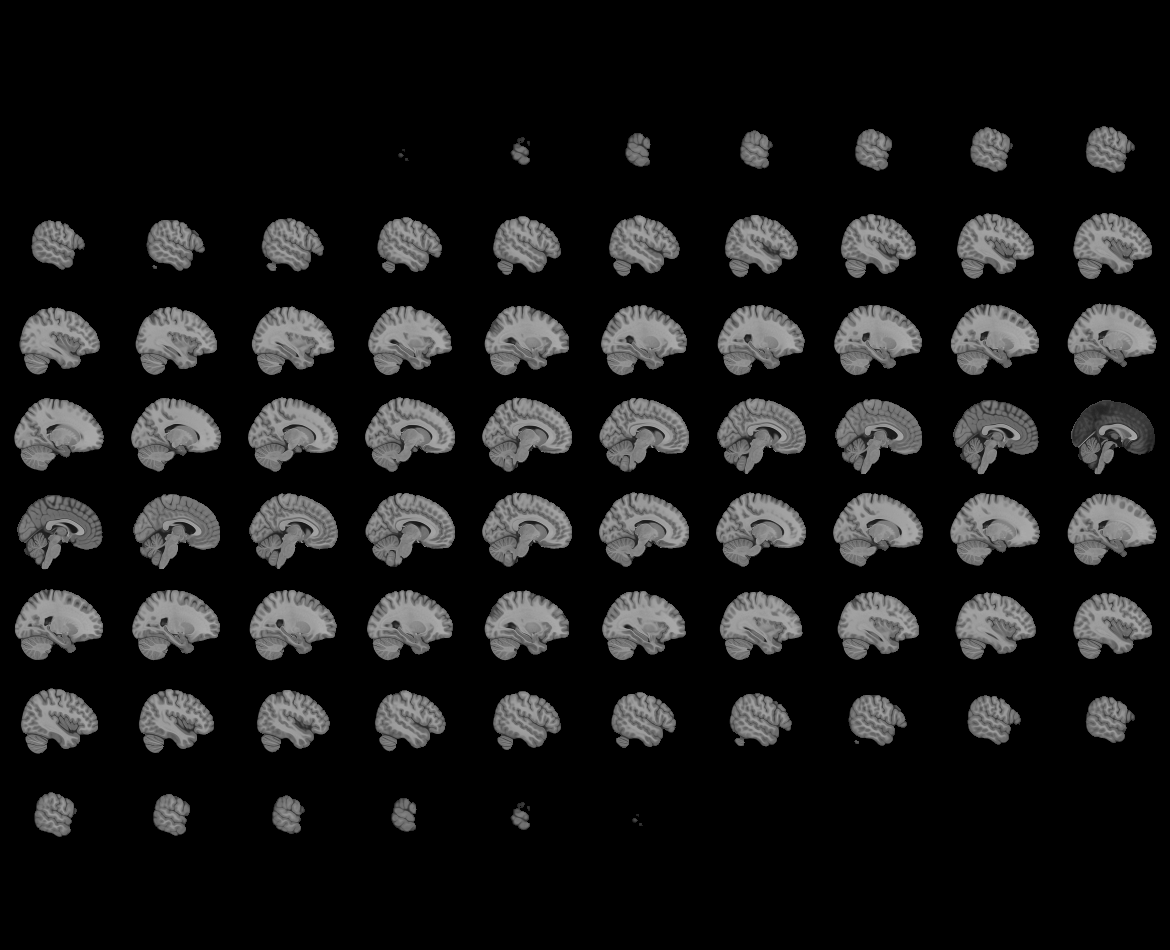
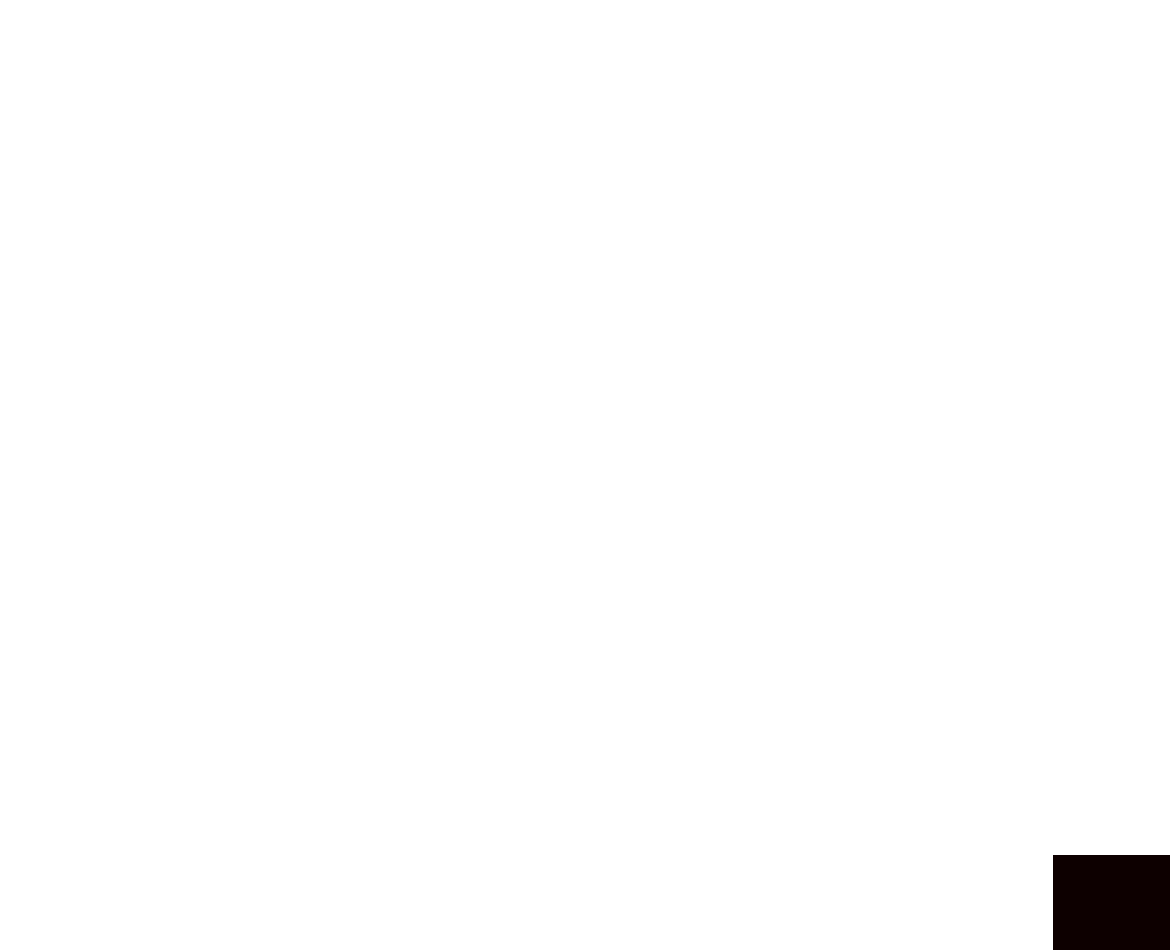

In [25]:
view = plotting.view_img(roi_mask[-1])
view

In [23]:
for roi in roi_bin:
# print(f'The ROI mask dimension is: {kastner_resample_bin.shape}')
# total_voxels_count = kastner_resample_bin.shape[0] * kastner_resample_bin.shape[1] * kastner_resample_bin.shape[2]
# print(f'The total number of voxels is: {total_voxels_count}')
    print(f'There are {np.count_nonzero(roi)} voxels in the ROI mask')

There are 2497 voxels in the ROI mask
There are 2389 voxels in the ROI mask
There are 2295 voxels in the ROI mask
There are 2174 voxels in the ROI mask
There are 1762 voxels in the ROI mask
There are 2130 voxels in the ROI mask
There are 1561 voxels in the ROI mask
There are 873 voxels in the ROI mask
There are 916 voxels in the ROI mask
There are 826 voxels in the ROI mask
There are 957 voxels in the ROI mask
There are 772 voxels in the ROI mask
There are 1249 voxels in the ROI mask
There are 1085 voxels in the ROI mask
There are 1368 voxels in the ROI mask
There are 1196 voxels in the ROI mask
There are 1911 voxels in the ROI mask
There are 1978 voxels in the ROI mask
There are 1649 voxels in the ROI mask
There are 1585 voxels in the ROI mask
There are 1244 voxels in the ROI mask
There are 1307 voxels in the ROI mask
There are 1166 voxels in the ROI mask
There are 1434 voxels in the ROI mask
There are 2688 voxels in the ROI mask


In [24]:
kastner_dict = dict(zip(roi_labels, roi_bin))

Load AAL3 mask

In [25]:
aal3_label = [
 'ACCpre',
 'ACCsub',
 'ACCsup',
 'Amygdala',
 'Angular',
 'Calcarine',
 'Caudate',
#  'CingulateAnt',
#  'CingulateMid',
#  'CingulatePost',
 'Cuneus',
 'Fusiform',
 'Hippocampus',
 'Insula',
 'Lingual',
 'ParaHippocampal',
 'Postcentral',
 'Precentral',
 'Precuneus',
 'Putamen',
 'ThalPuL'
]

In [26]:
aal3_bins = []
aal3_masks = []

for i in range(len(aal3_label)):
    aal3_nii = nib.load(f'F:\yujun\projects\data\masks\AAL3\\new\{aal3_label[i]}.nii.gz')
    aal3_resample = resample_img(aal3_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    aal3_bin = np.where(aal3_resample.get_fdata() > 0, 1, 0)
    aal3_masks.append(nib.Nifti1Image(aal3_bin, temp_nii_data.affine))
    aal3_bins.append(aal3_bin)

In [27]:
print(f"original size: {aal3_nii.get_fdata().shape}")
print(f"resampled size: {aal3_bin.shape}")

original size: (91, 109, 91)
resampled size: (79, 95, 79)


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "



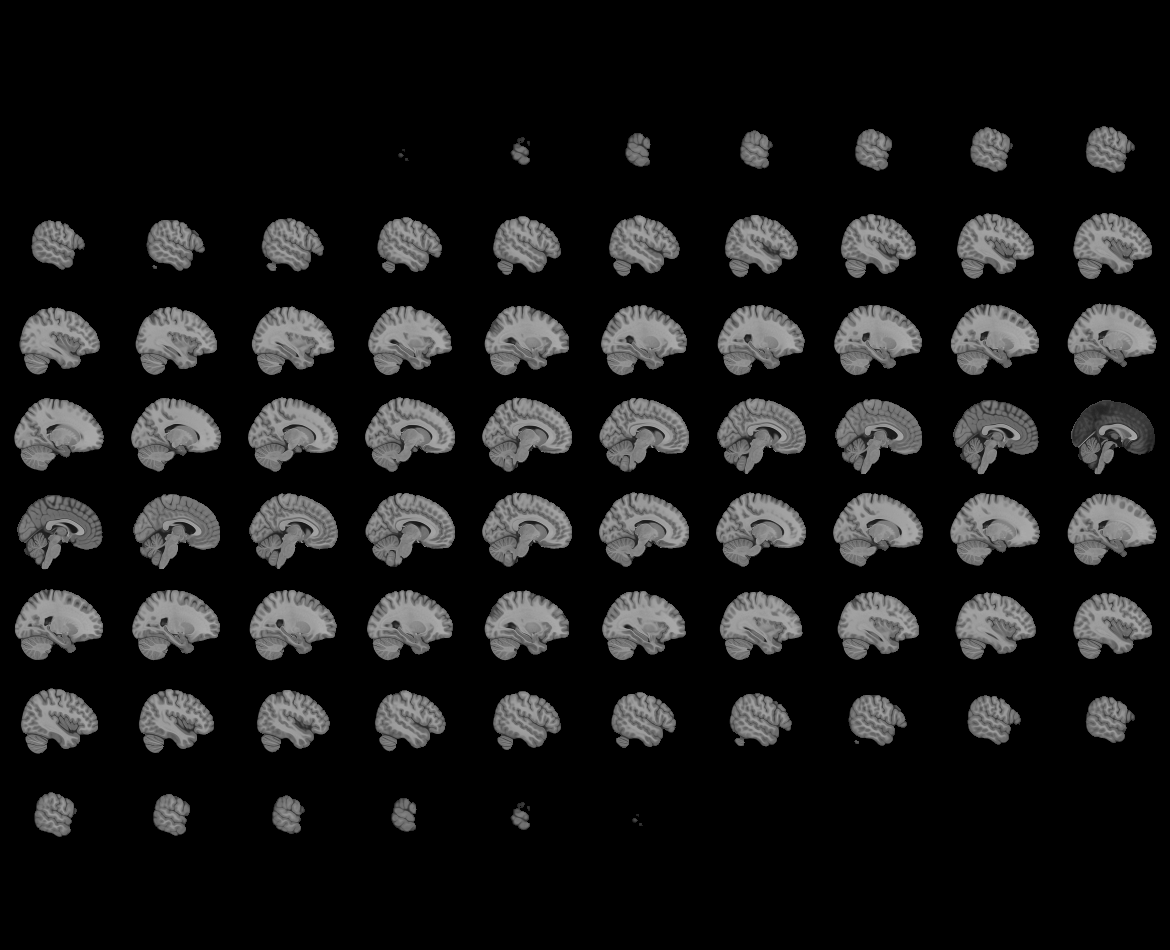
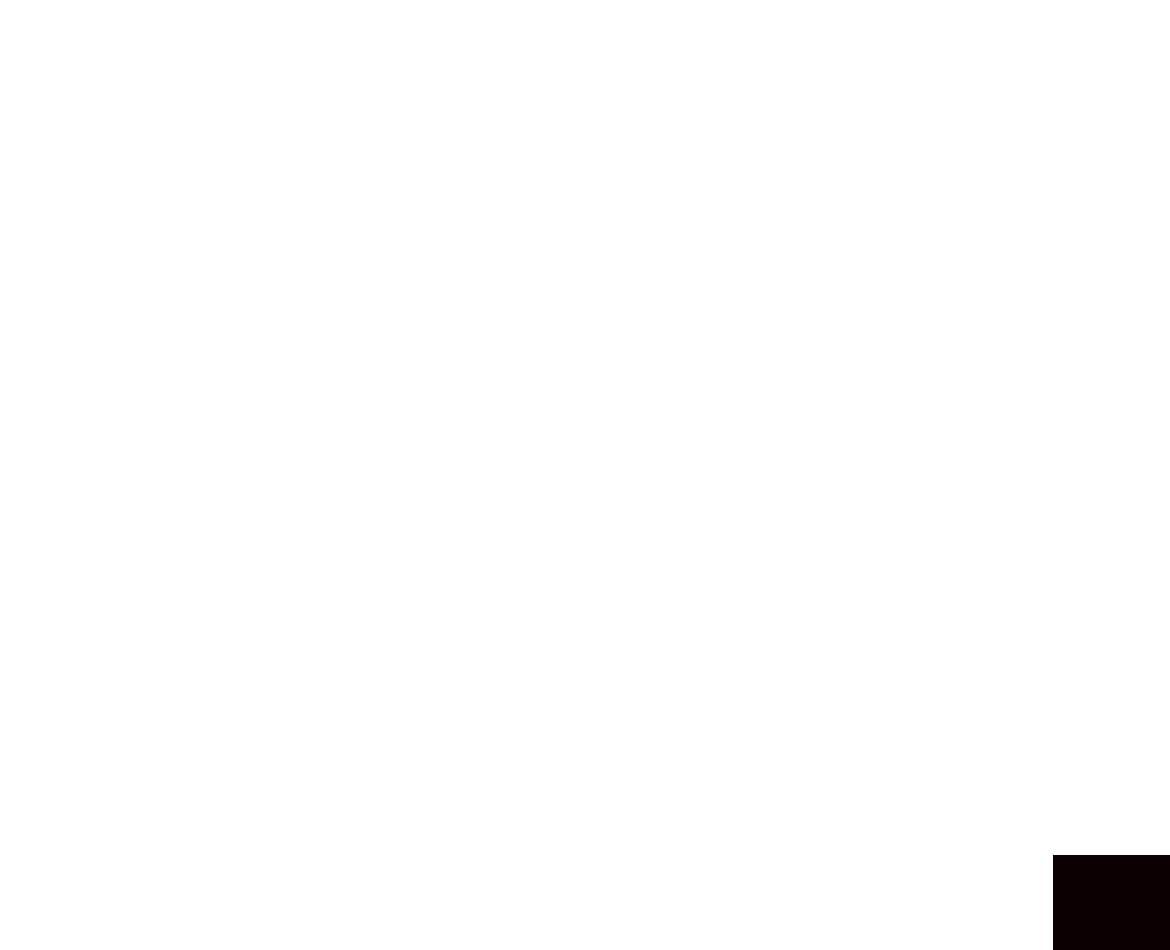

In [31]:
roi = 'Amygdala'
view = plotting.view_img(aal3_masks[aal3_label.index(roi)], title = f"{roi}")
view

In [28]:
aal3_dict = dict(zip(aal3_label, aal3_bins))

In [29]:
kastner_dict.update(aal3_dict)

In [30]:
roi_dict = kastner_dict
len(roi_dict)

43

In [31]:
roi_dict.keys()

dict_keys(['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2', 'MST', 'hMT', 'LO2', 'LO1', 'V3b', 'V3a', 'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5', 'SPL1', 'FEF', 'ACCpre', 'ACCsub', 'ACCsup', 'Amygdala', 'Angular', 'Calcarine', 'Caudate', 'Cuneus', 'Fusiform', 'Hippocampus', 'Insula', 'Lingual', 'ParaHippocampal', 'Postcentral', 'Precentral', 'Precuneus', 'Putamen', 'ThalPuL'])

Apply mask

In [32]:
print(len(roi_dict))
print(roi_dict['Amygdala'].shape)

43
(79, 95, 79)


In [33]:
for roi_name, roi_bin in roi_dict.items():
    print(f'There are {np.count_nonzero(roi_bin)} voxels in the ROI: {roi_name}')

There are 2497 voxels in the ROI: V1v
There are 2389 voxels in the ROI: V1d
There are 2295 voxels in the ROI: V2v
There are 2174 voxels in the ROI: V2d
There are 1762 voxels in the ROI: V3v
There are 2130 voxels in the ROI: V3d
There are 1561 voxels in the ROI: hV4
There are 873 voxels in the ROI: VO1
There are 916 voxels in the ROI: VO2
There are 826 voxels in the ROI: PHC1
There are 957 voxels in the ROI: PHC2
There are 772 voxels in the ROI: MST
There are 1249 voxels in the ROI: hMT
There are 1085 voxels in the ROI: LO2
There are 1368 voxels in the ROI: LO1
There are 1196 voxels in the ROI: V3b
There are 1911 voxels in the ROI: V3a
There are 1978 voxels in the ROI: IPS0
There are 1649 voxels in the ROI: IPS1
There are 1585 voxels in the ROI: IPS2
There are 1244 voxels in the ROI: IPS3
There are 1307 voxels in the ROI: IPS4
There are 1166 voxels in the ROI: IPS5
There are 1434 voxels in the ROI: SPL1
There are 2688 voxels in the ROI: FEF
There are 1275 voxels in the ROI: ACCpre
There

SVM

In [34]:
stimuli

,OriginalOrder,img,emotion_type,AI,group
0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...
595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,2446.jpg,neutral,NO,neutral
598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [39]:
decode_ids = []
decode_names = []

decode_ids.append(np.where((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral'))[0])
decode_names.append('Decode pleasant vs. neutral images.')
decode_ids.append(np.where((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant'))[0])
decode_names.append('Decode pleasant vs. unpleasant images.')
decode_ids.append(np.where((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral'))[0])
decode_names.append('Decode unpleasant vs. neutral images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
decode_names.append('Decode pleasant vs. neutral (natrual) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'NO'))[0])
decode_names.append('Decode pleasant vs. unpleasant (natrual) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
decode_names.append('Decode unpleasant vs. neutral (natrual) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
decode_names.append('Decode pleasant vs. neutral (AI) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'YES'))[0])
decode_names.append('Decode pleasant vs. unpleasant (AI) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
decode_names.append('Decode unpleasant vs. neutral (AI) images.')
decode_ids.append(np.where( (stimuli['emotion_type'] == 'pleasant'))[0])
decode_names.append('Decode AI vs. natrual (pleasant) images.')
decode_ids.append(np.where( (stimuli['emotion_type'] == 'neutral'))[0])
decode_names.append('Decode AI vs. natrual (neutral) images.')
decode_ids.append(np.where( (stimuli['emotion_type'] == 'unpleasant'))[0])
decode_names.append('Decode AI vs. natrual (unpleasant) images.')

In [36]:
from sklearn.model_selection import RepeatedStratifiedKFold

In [35]:
test_roi_dict = {k: v for k, v in list(roi_dict.items())[:3]}

In [42]:
flat_betas = beta_series.reshape((600, -1))

# Create an empty dictionary to store the results
betas_dict = {}

# Stratified 10-fold cross-validation
rskf  = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

rois = []
# Iterate through the values of roi_dict
for roi_name, roi_bin in tqdm(roi_dict.items()):
    flat_roi = roi_bin.ravel()
    roi_betas = flat_betas[:, flat_roi == 1]

    print(f'Now decoding {roi_name}')

    cases = []
    for i, decode_id in enumerate(decode_ids):
        data = roi_betas[decode_id, :]  # (600, number of roi voxels)
        if i < 9:
            labels = stimuli['emotion_type'][decode_id].reset_index(drop=True)
        elif i >= 9:
            labels = stimuli['AI'][decode_id].reset_index(drop=True)

        linear_svc_scores = []
        
        # 10-fold cross-validation
        for train_index, test_index in rskf.split(data, labels):
            X_train, X_test = data[train_index], data[test_index]
            y_train, y_test = labels[train_index], labels[test_index]

            # Create SVC classifiers with different kernels
            linear_svc = SVC(kernel='linear', random_state=42)

            # Fit the model
            linear_svc.fit(X_train, y_train)

            # Evaluate the model
            linear_score = linear_svc.score(X_test, y_test)
            linear_svc_scores.append(linear_score)

        # Compute average accuracy for Linear SVC over the 10 folds
        avg_linear_score = np.mean(linear_svc_scores)

        # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
        # print("Average Linear SVC accuracy:", avg_linear_score)
        # print("------------------")
        cases.append(avg_linear_score)

    # print('=============================================')
    rois.append(cases)


  0%|          | 0/43 [00:00<?, ?it/s]

Now decoding V1v


  2%|▏         | 1/43 [05:33<3:53:23, 333.41s/it]

Now decoding V1d


  5%|▍         | 2/43 [09:59<3:20:44, 293.78s/it]

Now decoding V2v


  7%|▋         | 3/43 [15:12<3:21:42, 302.56s/it]

Now decoding V2d


  9%|▉         | 4/43 [19:03<2:58:13, 274.19s/it]

Now decoding V3v


 12%|█▏        | 5/43 [23:26<2:51:10, 270.29s/it]

Now decoding V3d


 14%|█▍        | 6/43 [26:38<2:30:16, 243.69s/it]

Now decoding hV4


 16%|█▋        | 7/43 [32:19<2:45:16, 275.46s/it]

Now decoding VO1


 19%|█▊        | 8/43 [37:11<2:43:50, 280.87s/it]

Now decoding VO2


 21%|██        | 9/43 [40:01<2:19:26, 246.07s/it]

Now decoding PHC1


 23%|██▎       | 10/43 [42:01<1:53:58, 207.22s/it]

Now decoding PHC2


 26%|██▌       | 11/43 [43:42<1:33:10, 174.70s/it]

Now decoding MST


 28%|██▊       | 12/43 [48:32<1:48:22, 209.75s/it]

Now decoding hMT


 30%|███       | 13/43 [51:39<1:41:22, 202.74s/it]

Now decoding LO2


 33%|███▎      | 14/43 [55:13<1:39:37, 206.13s/it]

Now decoding LO1


 35%|███▍      | 15/43 [58:15<1:32:54, 199.07s/it]

Now decoding V3b


 37%|███▋      | 16/43 [1:01:32<1:29:16, 198.38s/it]

Now decoding V3a


 40%|███▉      | 17/43 [1:04:13<1:21:06, 187.18s/it]

Now decoding IPS0


 42%|████▏     | 18/43 [1:06:09<1:09:03, 165.76s/it]

Now decoding IPS1


 44%|████▍     | 19/43 [1:08:14<1:01:26, 153.59s/it]

Now decoding IPS2


 47%|████▋     | 20/43 [1:11:26<1:03:12, 164.88s/it]

Now decoding IPS3


 49%|████▉     | 21/43 [1:15:30<1:09:13, 188.81s/it]

Now decoding IPS4


 51%|█████     | 22/43 [1:19:37<1:12:11, 206.27s/it]

Now decoding IPS5


 53%|█████▎    | 23/43 [1:23:06<1:08:59, 207.00s/it]

Now decoding SPL1


 56%|█████▌    | 24/43 [1:26:46<1:06:45, 210.83s/it]

Now decoding FEF


 58%|█████▊    | 25/43 [1:28:28<53:28, 178.25s/it]  

Now decoding ACCpre


 60%|██████    | 26/43 [1:30:39<46:28, 164.06s/it]

Now decoding ACCsub


 63%|██████▎   | 27/43 [1:34:54<51:01, 191.33s/it]

Now decoding ACCsup


 65%|██████▌   | 28/43 [1:36:23<40:08, 160.60s/it]

Now decoding Amygdala


 67%|██████▋   | 29/43 [1:39:00<37:15, 159.67s/it]

Now decoding Angular


 70%|██████▉   | 30/43 [1:41:06<32:23, 149.51s/it]

Now decoding Calcarine


 72%|███████▏  | 31/43 [1:44:43<33:55, 169.65s/it]

Now decoding Caudate


 74%|███████▍  | 32/43 [1:46:02<26:07, 142.51s/it]

Now decoding Cuneus


 77%|███████▋  | 33/43 [1:48:54<25:13, 151.36s/it]

Now decoding Fusiform


 79%|███████▉  | 34/43 [1:51:59<24:14, 161.56s/it]

Now decoding Hippocampus


 81%|████████▏ | 35/43 [1:53:13<18:02, 135.34s/it]

Now decoding Insula


 84%|████████▎ | 36/43 [1:55:07<15:01, 128.75s/it]

Now decoding Lingual


 86%|████████▌ | 37/43 [1:58:20<14:47, 147.97s/it]

Now decoding ParaHippocampal


 88%|████████▊ | 38/43 [1:59:47<10:49, 129.96s/it]

Now decoding Postcentral


 91%|█████████ | 39/43 [2:05:16<12:38, 189.56s/it]

Now decoding Precentral


 93%|█████████▎| 40/43 [2:10:56<11:43, 234.67s/it]

Now decoding Precuneus


 95%|█████████▌| 41/43 [2:16:46<08:58, 269.39s/it]

Now decoding Putamen


 98%|█████████▊| 42/43 [2:18:02<03:31, 211.11s/it]

Now decoding ThalPuL


100%|██████████| 43/43 [2:18:32<00:00, 193.32s/it]


## Cross day decoding

In [50]:
flat_betas = beta_series.reshape((600, -1))

# Create an empty dictionary to store the results
betas_dict = {}

# Stratified 10-fold cross-validation
rskf  = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

rois = []
# Iterate through the values of roi_dict
for roi_name, roi_bin in tqdm(test_roi_dict.items()):
    flat_roi = roi_bin.ravel()
    roi_betas = flat_betas[:, flat_roi == 1]

    print(f'Now decoding {roi_name}')

    data = roi_betas  # (600, number of roi voxels)
    labels = stimuli['emotion_type'].reset_index(drop=True)

    linear_svc_scores = []
    
    # 10-fold cross-validation
    for train_index, test_index in rskf.split(data, labels):
        X_train, X_test = data[:300], data[-300:]
        y_train, y_test = labels[:300], labels[-300:]

        # Create SVC classifiers with different kernels
        linear_svc = SVC(kernel='linear', random_state=42)

        # Fit the model
        linear_svc.fit(X_train, y_train)

        # Evaluate the model
        linear_score = linear_svc.score(X_test, y_test)
        linear_svc_scores.append(linear_score)

    # Compute average accuracy for Linear SVC over the 10 folds
    avg_linear_score = np.mean(linear_svc_scores)

    # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
    # print("Average Linear SVC accuracy:", avg_linear_score)
    # print("------------------")
    rois.append(avg_linear_score)



  0%|          | 0/3 [00:00<?, ?it/s]

Now decoding V1v


 33%|███▎      | 1/3 [00:36<01:13, 36.69s/it]

Now decoding V1d


 67%|██████▋   | 2/3 [01:09<00:34, 34.70s/it]

Now decoding V2v


100%|██████████| 3/3 [01:38<00:00, 32.97s/it]


In [51]:
np.array(rois).shape

(3,)

In [52]:
len(test_roi_dict)

3

In [54]:
rois

[0.41333333333333344, 0.3533333333333334, 0.40333333333333315]

TypeError: Invalid shape (3,) for image data

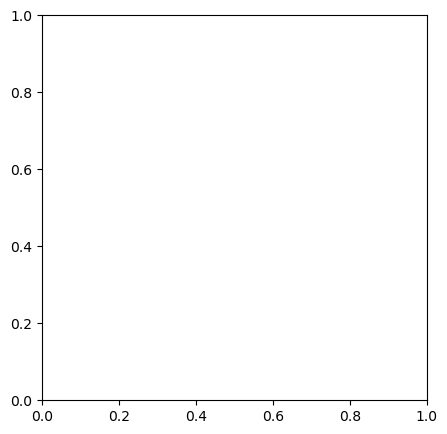

In [53]:
from mlxtend.plotting import heatmap
heatmap(np.array(rois).T, figsize=(20, 5))
plt.title("Subject 1")
plt.show()

## Cross day decoding - end

In [43]:
np.array(rois).shape

(43, 12)

In [44]:
np.save('./outputs/Sub1_43roi_sub2.npy', rois)

In [57]:
rois_all = []
rois_all.append(np.load('./outputs/Sub1_43roi.npy'))
rois_all.append(np.load('./outputs/Sub1_43roi_sub2.npy'))

In [60]:
rois_all = np.array(rois_all)
rois_avg = np.average(rois_all, axis=0)

(2, 43, 12)

In [63]:
rois_avg.shape

(43, 12)

In [47]:
roi_names = roi_dict.keys()

In [52]:
decode_names = []
decode_names.append('pleasant vs. neutral')
decode_names.append('pleasant vs. unpleasant')
decode_names.append('unpleasant vs. neutral')
decode_names.append('pleasant vs. neutral (natrual)')
decode_names.append('pleasant vs. unpleasant (natrual)')
decode_names.append('unpleasant vs. neutral (natrual)')
decode_names.append('pleasant vs. neutral (AI)')
decode_names.append('pleasant vs. unpleasant (AI)')
decode_names.append('unpleasant vs. neutral (AI)')
decode_names.append('AI vs. natrual (pleasant)')
decode_names.append('AI vs. natrual (neutral)')
decode_names.append('AI vs. natrual (unpleasant)')

In [48]:
deselect_roi_id = [42,41,31,30,29, 25, 26, 27]

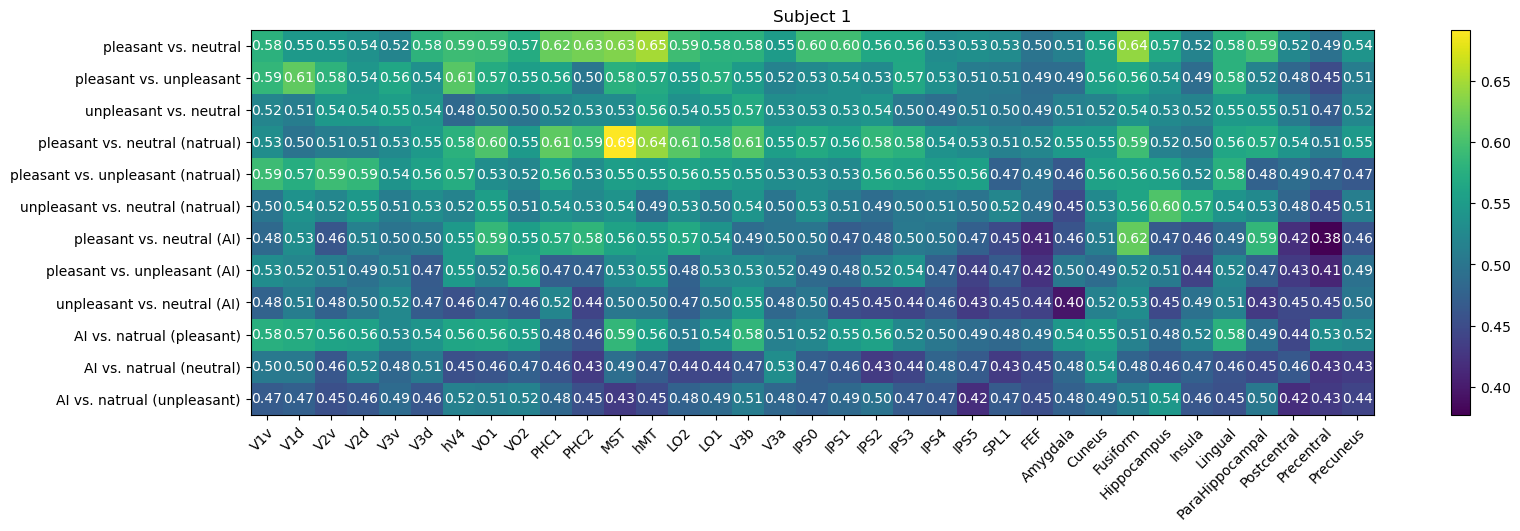

In [56]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(decode_names) if i not in deselect_roi_id], figsize=(20, 5))
plt.title("Subject 1")
plt.show()

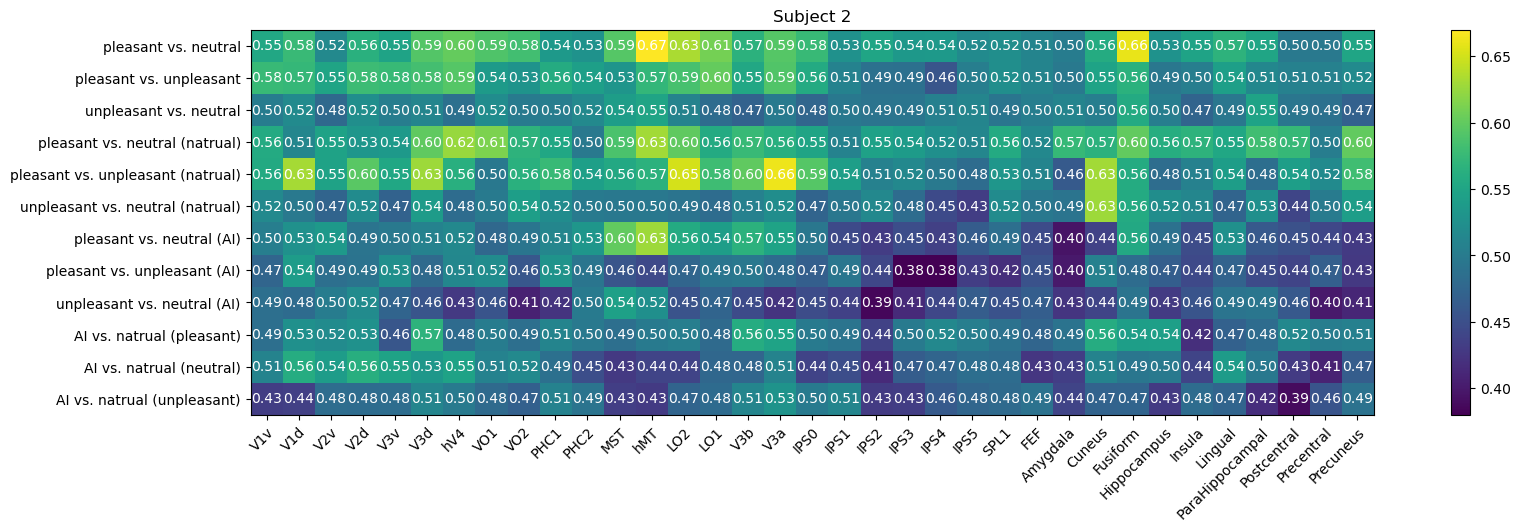

In [65]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois_all[1]).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(decode_names) if i not in deselect_roi_id], figsize=(20, 5))
plt.title("Subject 2")
plt.show()

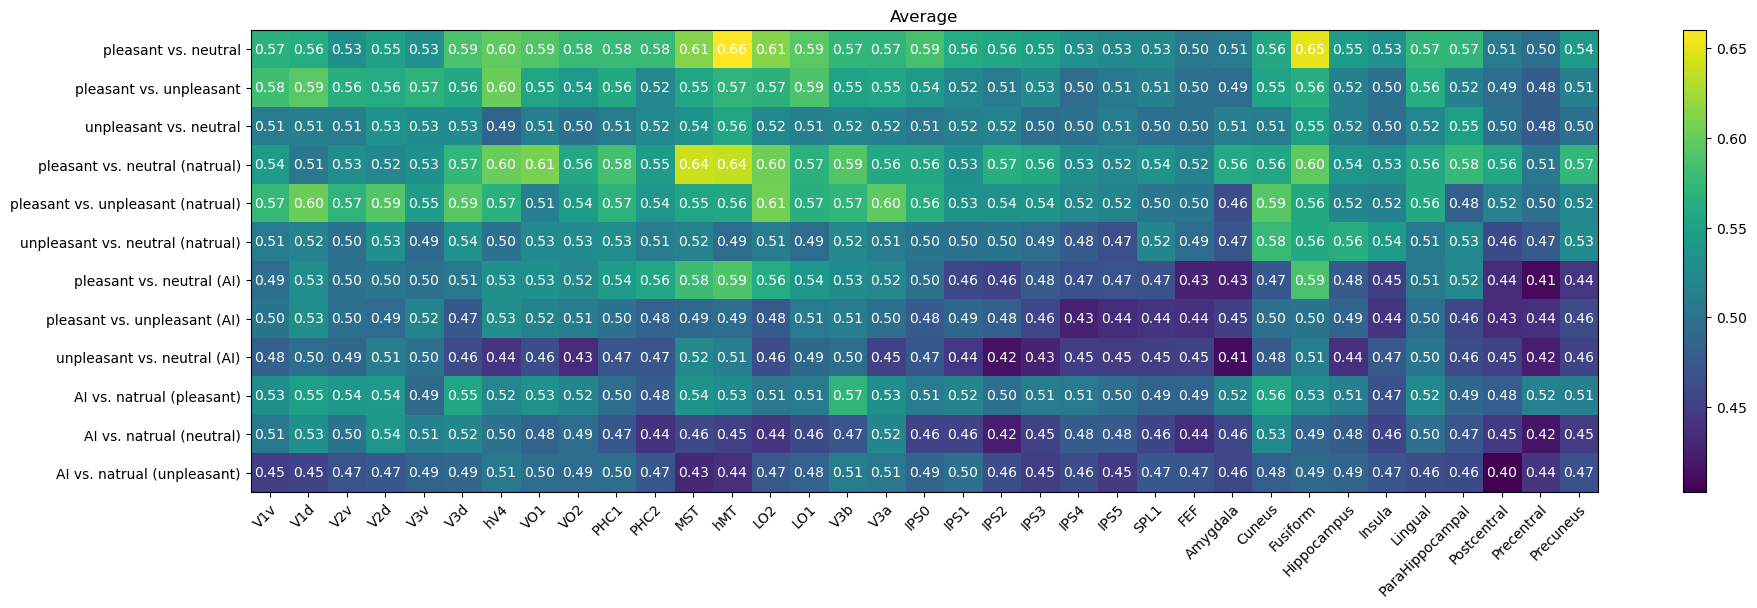

In [68]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois_avg).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(decode_names) if i not in deselect_roi_id], figsize=(22, 6))
plt.title("Average")
plt.show()

In [69]:
xdecode_ids = []
xdecode_names = []

xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'YES'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])

xdecode_names.append('AI (pleasant vs. neutral)')
xdecode_names.append('AI (pleasant vs. unpleasant)')
xdecode_names.append('AI (unpleasant vs. neutral)')
xdecode_names.append('natrual (pleasant vs. neutral)')
xdecode_names.append('natrual (pleasant vs. unpleasant)')
xdecode_names.append('natrual (unpleasant vs. neutral)')

In [70]:
flat_betas = beta_series.reshape((600, -1))

In [82]:
roi_bin.shape

(79, 95, 79)

In [71]:
rois_xdecode = []
# Iterate through the values of roi_dict
for roi_name, roi_bin in tqdm(roi_dict.items()):
    flat_roi = roi_bin.ravel()
    roi_betas = flat_betas[:, flat_roi == 1]

    # print(f'Now decoding {roi_name}')

    cases = []
    for i, xdecode_id in enumerate(xdecode_ids):
        data_train = roi_betas[xdecode_id, :]  # (600, number of roi voxels)
        label_train = stimuli['emotion_type'][xdecode_id].reset_index(drop=True)
        if i == 0:
            data_test = roi_betas[xdecode_ids[3], :]
            label_test = stimuli['emotion_type'][xdecode_ids[3]].reset_index(drop=True)
        elif i == 1:
            data_test = roi_betas[xdecode_ids[4], :]
            label_test = stimuli['emotion_type'][xdecode_ids[4]].reset_index(drop=True)
        elif i == 2:
            data_test = roi_betas[xdecode_ids[5], :]
            label_test = stimuli['emotion_type'][xdecode_ids[5]].reset_index(drop=True)
        elif i == 3:
            data_test = roi_betas[xdecode_ids[0], :]
            label_test = stimuli['emotion_type'][xdecode_ids[0]].reset_index(drop=True)
        elif i == 4:
            data_test = roi_betas[xdecode_ids[1], :]
            label_test = stimuli['emotion_type'][xdecode_ids[1]].reset_index(drop=True)
        else:
            data_test = roi_betas[xdecode_ids[2], :]
            label_test = stimuli['emotion_type'][xdecode_ids[2]].reset_index(drop=True)

        # Create SVC classifiers with different kernels
        linear_svc = SVC(kernel='linear')

        # Fit the model
        linear_svc.fit(data_train, label_train)

        # Evaluate the model
        linear_score = linear_svc.score(data_test, label_test)

        # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
        # print("Average Linear SVC accuracy:", avg_linear_score)
        # print("------------------")
        cases.append(linear_score)

    # print('=============================================')
    rois_xdecode.append(cases)

100%|██████████| 43/43 [01:01<00:00,  1.42s/it]


In [80]:
len(rois_xdecode)

43

In [72]:
np.save('./outputs/Sub1243ro_xdeco.npy', rois_xdecode)

In [151]:
# deselect_roi_names = ['ACCpre', 'ACCsub', 'ACCsup', 'Angular', 'Calcarine', 'Caudate', 'CingulateMid', 'CingulatePost', 'Putamen', 'ThalPuA', 'ThalPuM', 'ThalPuL', 'ThalPuI']
# deselect_roi_id = [list(roi_dict.keys()).index(item) for item in deselect_roi_names]
deselect_roi_id = [42,41,31,30,29, 25, 26, 27]

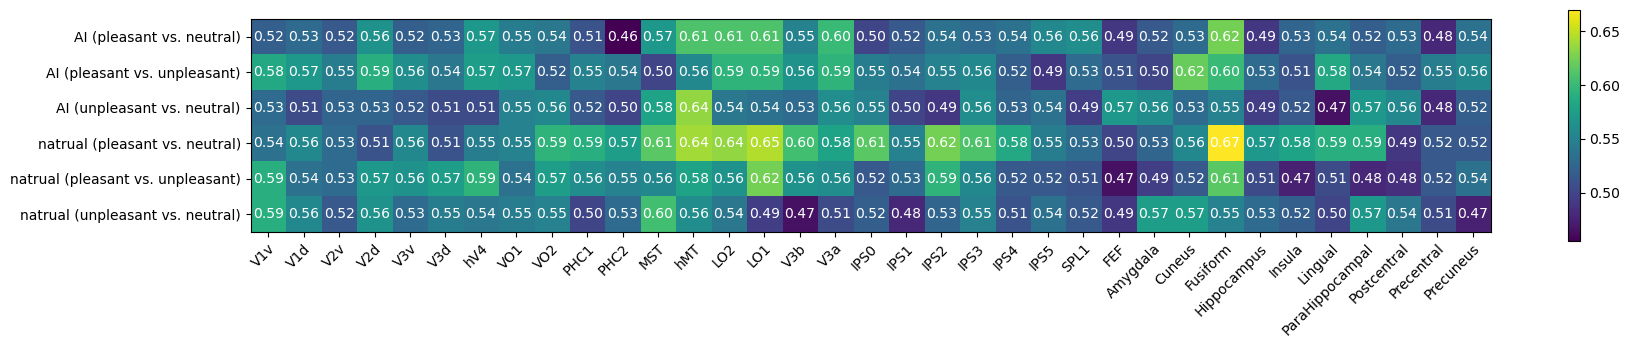

In [76]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois_xdecode).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_dict) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id], figsize=(20, 3))
plt.show()

In [83]:
rois_all_xdeco = []
rois_all_xdeco.append(np.load('./outputs/Sub1_43ro_xdeco.npy'))
rois_all_xdeco.append(np.load('./outputs/Sub2_43ro_xdeco.npy'))

In [84]:
rois_all_xdeco = np.array(rois_all_xdeco)
rois_avg_xdeco = np.average(rois_all_xdeco, axis=0)

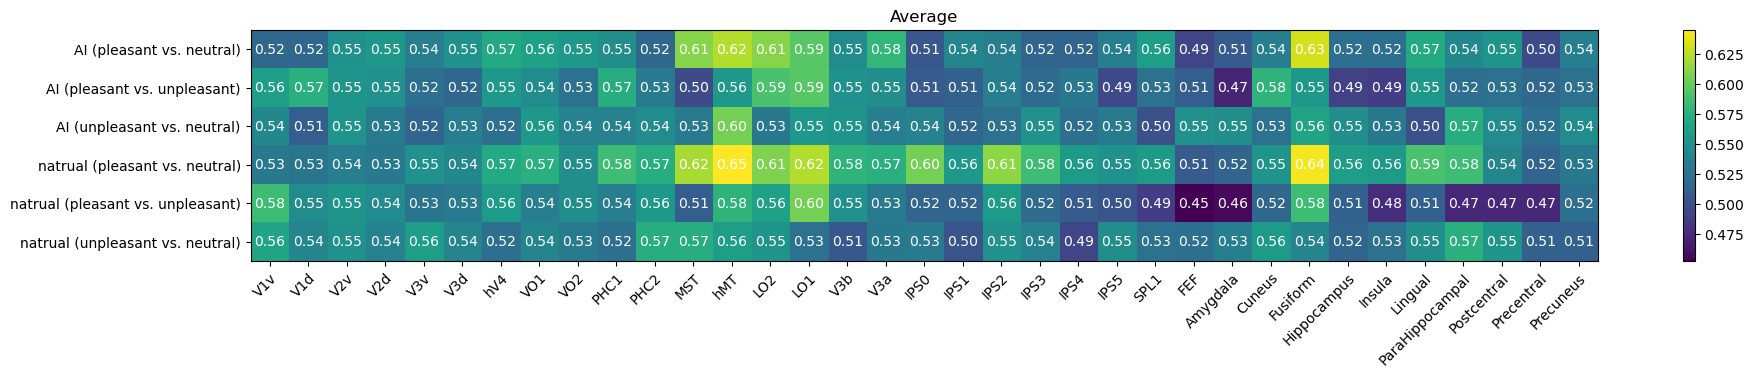

In [108]:
heatmap(np.delete(np.array(rois_avg_xdeco).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id], figsize=(22, 3))


plt.title("Average")

plt.show()



In [106]:
rois_avg_xdeco_arr = np.delete(np.array(rois_avg_xdeco).T, deselect_roi_id,axis=1)

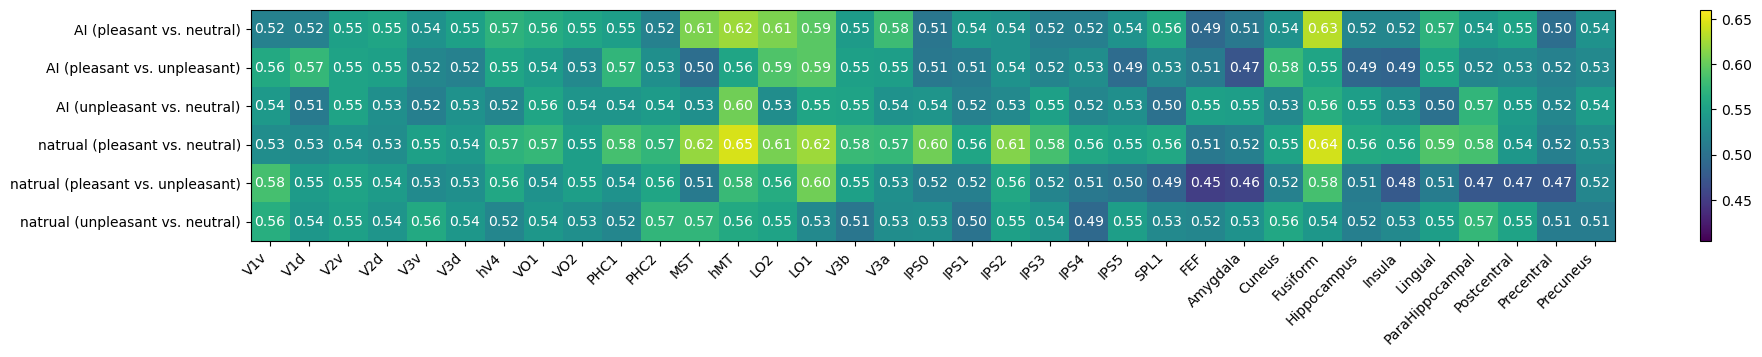

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_xdeco_arr

# Set the figure size
plt.figure(figsize=(22, 3))

# Create the heatmap
plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id]
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()

Decoding differences

In [128]:
rois_avg.shape

(43, 12)

In [129]:
rois_avg_xdeco.shape

(43, 6)

In [134]:
rois_avg_nat1 = rois_avg[:,0:3]
rois_avg_nat2 = rois_avg[:,3:6]
rois_avg_nat3 = rois_avg[:,6:9]
rois_avg_xdeco_nat = rois_avg_xdeco[:,0:3]

rois_avg_diif_nat1 = rois_avg_nat1-rois_avg_xdeco_nat
rois_avg_diif_nat2 = rois_avg_nat2-rois_avg_xdeco_nat
rois_avg_diif_nat3 = rois_avg_nat3-rois_avg_xdeco_nat
rois_avg_diif_nat = np.hstack((rois_avg_diif_nat1, rois_avg_diif_nat2, rois_avg_diif_nat3))

In [140]:

rois_avg_diif_nat.shape

(43, 9)

In [145]:
len(xdecode_names)

6

In [165]:
xdecode_diff_names = ['pl-nt,ALL dc-Nat. xdc',
    'pl-up,ALL dc-Nat. xdc',
    'up-nt,ALL dc-Nat. xdc',
    'pl-nt,Natural dc-Nat. xdc',
    'pl-up,Natural dc-Nat. xdc',
    'up-nt,Natural dc-Nat. xdc',
    'pl-nt,AI dc-Nat. xdc',
    'pl-up,AI dc-Nat. xdc',
    'up-nt,AI dc-Nat. xdc',
 ]

In [150]:
len(roi_names)

43

In [153]:
heatmap_data.shape

(9, 43)

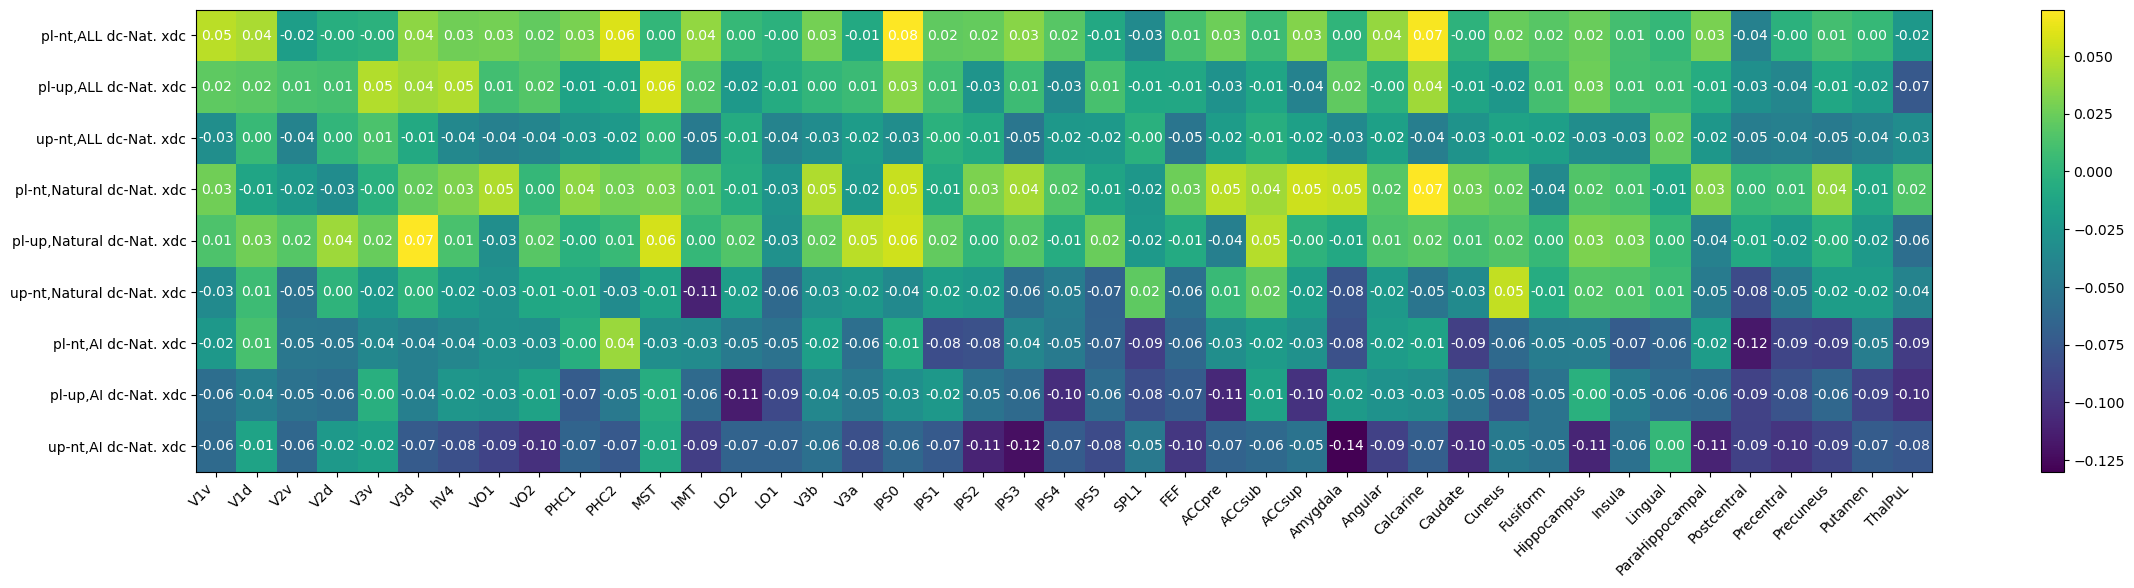

In [166]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_diif_nat.T

# Set the figure size
plt.figure(figsize=(28, 6))

# Create the heatmap
# plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)
plt.imshow(heatmap_data, cmap='viridis', aspect='auto',vmin=-0.13, vmax=0.07)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
# column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
column_names = roi_names
row_names = xdecode_diff_names
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()

- AI xdecode

In [157]:
rois_avg_xdeco.shape

(43, 6)

In [159]:
rois_avg_nat1 = rois_avg[:,0:3]
rois_avg_nat2 = rois_avg[:,3:6]
rois_avg_nat3 = rois_avg[:,6:9]
rois_avg_xdeco_ai = rois_avg_xdeco[:,3:6]

rois_avg_diif_ai1 = rois_avg_nat1-rois_avg_xdeco_ai
rois_avg_diif_ai2 = rois_avg_nat2-rois_avg_xdeco_ai
rois_avg_diif_ai3 = rois_avg_nat3-rois_avg_xdeco_ai
rois_avg_diif_ai = np.hstack((rois_avg_diif_ai1, rois_avg_diif_ai2, rois_avg_diif_ai3))

In [161]:
xdecode_diff_names = ['pl-nt,ALL dc-AI xdc',
    'pl-up,ALL dc-AI xdc',
    'up-nt,ALL dc-AI xdc',
    'pl-nt,Natural dc-AI xdc',
    'pl-up,Natural dc-AI. xdc',
    'up-nt,Natural dc-AI. xdc',
    'pl-nt,AI dc-AI xdc',
    'pl-up,AI dc-AI xdc',
    'up-nt,AI dc-AI xdc',
 ]

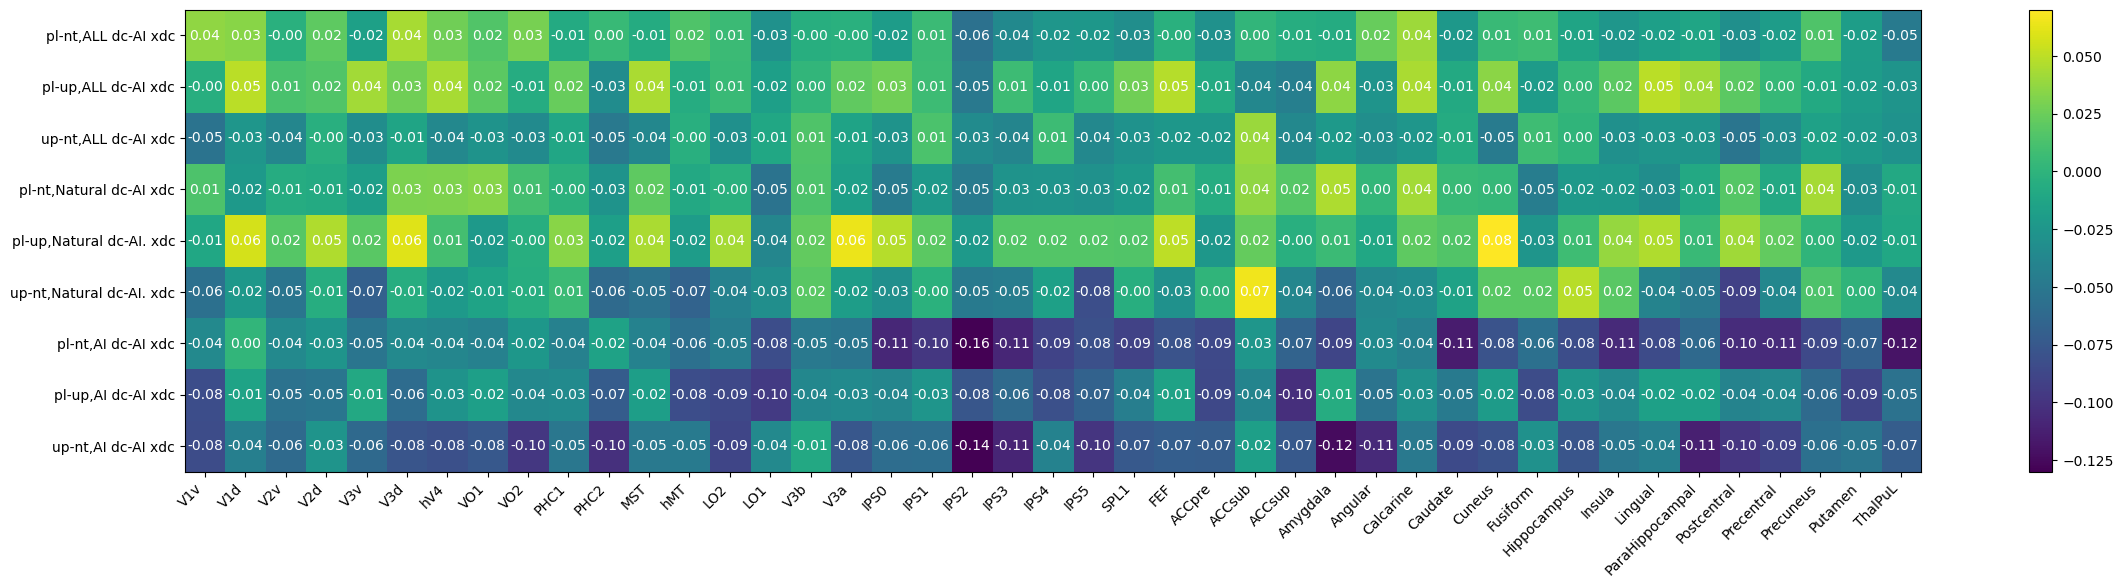

In [164]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_diif_ai.T

# Set the figure size
plt.figure(figsize=(28, 6))

# Create the heatmap
# plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)
plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=-0.13, vmax=0.07)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
# column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
column_names = roi_names
row_names = xdecode_diff_names
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()